In [16]:
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

In [17]:
import warnings

warnings.simplefilter("ignore", DeprecationWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [18]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*datetime.datetime.utcnow.*",
    category=DeprecationWarning
)

In [19]:
!pip install scikit-learn==1.9.0

In [20]:
import sklearn
print(sklearn.__version__)

1.9.0


In [21]:
!pip install mlxtend openpyxl

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [23]:


# Load the dataset
df = pd.read_csv("Online Retail.csv")

# Display the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [24]:
df.shape

(541909, 8)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB


In [26]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,15287.518434
std,218.081158,96.759853,1484.746041
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,14367.000000
50%,3.000000,2.080000,15287.000000
75%,10.000000,4.130000,16255.000000
max,80995.000000,38970.000000,18287.000000


In [27]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [28]:
df = df.dropna()

In [29]:
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]

In [30]:
df = df[df['Quantity'] > 0]

In [31]:
df = df[['InvoiceNo','Description','Quantity']]

In [32]:
df.head()

,InvoiceNo,Description,Quantity
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,WHITE METAL LANTERN,6
2,536365,CREAM CUPID HEARTS COAT HANGER,8
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6


In [33]:
basket = (df
          .groupby(['InvoiceNo','Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0))

In [34]:
print(basket.shape)

(20136, 4077)


In [37]:
basket_small = basket.head(5000)

In [38]:
basket_small = basket_small.apply(lambda x: x > 0)

In [52]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
frequent_itemsets = apriori(
    basket_small,
    min_support=0.02,
    use_colnames=True,
    low_memory=True
)

frequent_itemsets.head()

,support,itemsets
0,0.0340,( SET 2 TEA TOWELS I LOVE LONDON )
1,0.0276,(12 PENCILS SMALL TUBE RED RETROSPOT)
2,0.0222,(12 PENCILS SMALL TUBE SKULL)
3,0.0276,(3 HOOK PHOTO SHELF ANTIQUE WHITE)
4,0.0260,(3 PIECE SPACEBOY COOKIE CUTTER SET)


In [54]:
print(frequent_itemsets.shape)
frequent_itemsets.head(10)

(447, 2)


,support,itemsets
0,0.0340,( SET 2 TEA TOWELS I LOVE LONDON )
1,0.0276,(12 PENCILS SMALL TUBE RED RETROSPOT)
2,0.0222,(12 PENCILS SMALL TUBE SKULL)
3,0.0276,(3 HOOK PHOTO SHELF ANTIQUE WHITE)
4,0.0260,(3 PIECE SPACEBOY COOKIE CUTTER SET)
5,0.0242,(3 STRIPEY MICE FELTCRAFT)
6,0.0216,(4 TRADITIONAL SPINNING TOPS)
7,0.0530,(6 RIBBONS RUSTIC CHARM)
8,0.0246,(60 CAKE CASES DOLLY GIRL DESIGN)
9,0.0484,(60 TEATIME FAIRY CAKE CASES)


In [56]:
frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

,support,itemsets
322,0.1416,(WHITE HANGING HEART T-LIGHT HOLDER)
237,0.1196,(REGENCY CAKESTAND 3 TIER)
264,0.1050,(SET OF 3 CAKE TINS PANTRY DESIGN )
131,0.1010,(JUMBO BAG RED RETROSPOT)
109,0.0890,(HEART OF WICKER SMALL)
...,...,...
430,0.0200,"(RED RETROSPOT CHARLOTTE BAG, STRAWBERRY CHARL..."
95,0.0200,(GRAND CHOCOLATECANDLE)
361,0.0200,"(DOTCOM POSTAGE, LUNCH BAG RED RETROSPOT)"
323,0.0200,(WHITE METAL LANTERN)


In [57]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(60 TEATIME FAIRY CAKE CASES),(PACK OF 72 RETROSPOT CAKE CASES),0.0484,0.0756,0.0284,0.586777,7.761599,1.0,0.024741,2.237048,0.915469,0.297071,0.552982,0.481219
1,(ALARM CLOCK BAKELIKE ORANGE),(ALARM CLOCK BAKELIKE GREEN),0.0278,0.0546,0.0208,0.748201,13.703323,1.0,0.019282,3.754589,0.953533,0.337662,0.733659,0.564577
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.0376,0.0546,0.0214,0.569149,10.423973,1.0,0.019347,2.194262,0.939388,0.302260,0.544266,0.480545
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.0546,0.0520,0.0358,0.655678,12.609186,1.0,0.032961,2.753234,0.973866,0.505650,0.636791,0.672070
4,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.0520,0.0546,0.0358,0.688462,12.609186,1.0,0.032961,3.034617,0.971195,0.505650,0.670469,0.672070


In [58]:
rules = rules[['antecedents',
               'consequents',
               'support',
               'confidence',
               'lift']]

rules.head(20)

,antecedents,consequents,support,confidence,lift
0,(60 TEATIME FAIRY CAKE CASES),(PACK OF 72 RETROSPOT CAKE CASES),0.0284,0.586777,7.761599
1,(ALARM CLOCK BAKELIKE ORANGE),(ALARM CLOCK BAKELIKE GREEN),0.0208,0.748201,13.703323
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.0214,0.569149,10.423973
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.0358,0.655678,12.609186
4,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.0358,0.688462,12.609186
5,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.0218,0.579787,11.149755
6,(CANDLEHOLDER PINK HANGING HEART),(WHITE HANGING HEART T-LIGHT HOLDER),0.0278,0.723958,5.112700
7,(CHARLOTTE BAG PINK POLKADOT),(CHARLOTTE BAG SUKI DESIGN),0.0216,0.542714,12.060302
8,(RED RETROSPOT CHARLOTTE BAG),(CHARLOTTE BAG PINK POLKADOT),0.0248,0.521008,13.090663
9,(CHARLOTTE BAG PINK POLKADOT),(RED RETROSPOT CHARLOTTE BAG),0.0248,0.623116,13.090663


In [59]:
rules.sort_values(
    by='lift',
    ascending=False
)

,antecedents,consequents,support,confidence,lift
47,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.0220,0.748299,24.943311
46,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE BEDROOM ),0.0220,0.733333,24.943311
57,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.0204,0.962264,16.764184
59,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.0204,0.698630,16.323134
58,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.0204,0.871795,15.188064
...,...,...,...,...,...
6,(CANDLEHOLDER PINK HANGING HEART),(WHITE HANGING HEART T-LIGHT HOLDER),0.0278,0.723958,5.112700
41,(RECYCLING BAG RETROSPOT ),(JUMBO BAG RED RETROSPOT),0.0222,0.500000,4.950495
48,(RED HANGING HEART T-LIGHT HOLDER),(WHITE HANGING HEART T-LIGHT HOLDER),0.0358,0.670412,4.734548
61,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(REGENCY CAKESTAND 3 TIER),0.0238,0.556075,4.649455


In [60]:
rules.to_csv(
    "association_rules.csv",
    index=False
)

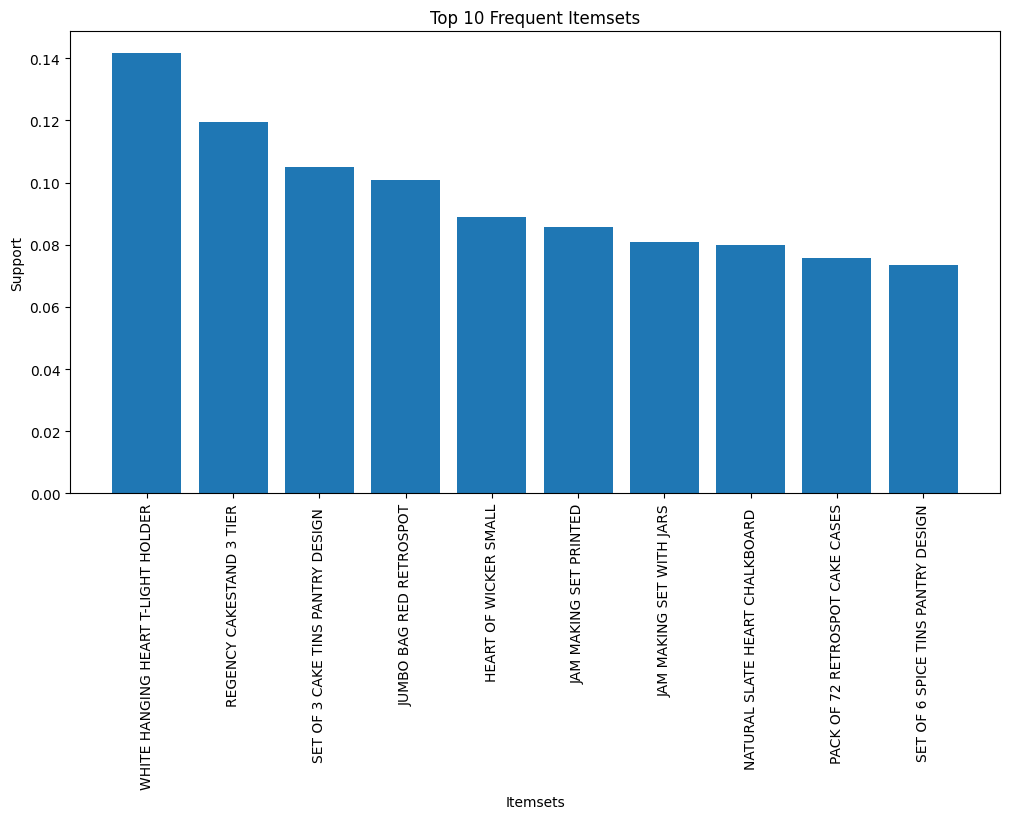

In [62]:
top10 = frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top10)),
    top10['support']
)

plt.xticks(
    range(len(top10)),
    [', '.join(list(x)) for x in top10['itemsets']],
    rotation=90
)

plt.title("Top 10 Frequent Itemsets")

plt.xlabel("Itemsets")

plt.ylabel("Support")

plt.show()

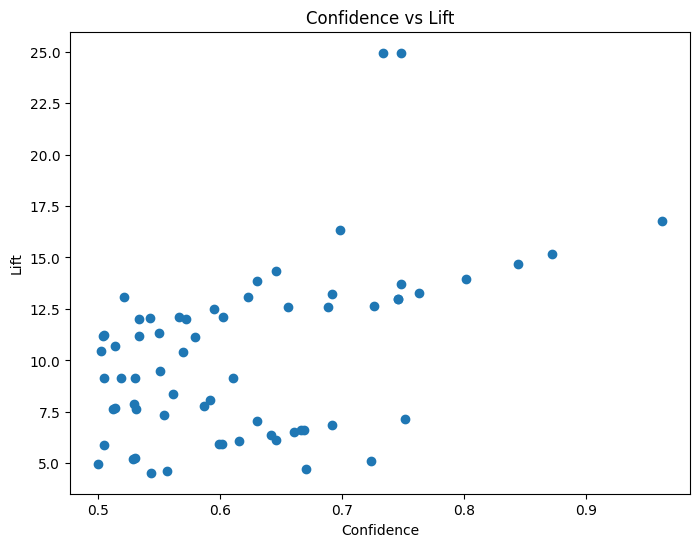

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(
    rules['confidence'],
    rules['lift']
)

plt.xlabel("Confidence")

plt.ylabel("Lift")

plt.title("Confidence vs Lift")

plt.show()

In [64]:
print(rules.shape)
rules.head()

(65, 5)


,antecedents,consequents,support,confidence,lift
0,(60 TEATIME FAIRY CAKE CASES),(PACK OF 72 RETROSPOT CAKE CASES),0.0284,0.586777,7.761599
1,(ALARM CLOCK BAKELIKE ORANGE),(ALARM CLOCK BAKELIKE GREEN),0.0208,0.748201,13.703323
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.0214,0.569149,10.423973
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.0358,0.655678,12.609186
4,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.0358,0.688462,12.609186


In [65]:
print(frequent_itemsets.shape)
frequent_itemsets.head()

(447, 2)


,support,itemsets
0,0.0340,( SET 2 TEA TOWELS I LOVE LONDON )
1,0.0276,(12 PENCILS SMALL TUBE RED RETROSPOT)
2,0.0222,(12 PENCILS SMALL TUBE SKULL)
3,0.0276,(3 HOOK PHOTO SHELF ANTIQUE WHITE)
4,0.0260,(3 PIECE SPACEBOY COOKIE CUTTER SET)


In [66]:
print("Total Transactions :", basket.shape[0])

print("Unique Products :", basket.shape[1])

print("Frequent Itemsets :", len(frequent_itemsets))

print("Association Rules :", len(rules))

Total Transactions : 20136
Unique Products : 4077
Frequent Itemsets : 447
Association Rules : 65
